# Root Phenotyping via Pose Estimation — Trait Extraction with `sleap-roots`

**Paper:** E.M. Berrigan et al., *"Fast and Efficient Root Phenotyping via Pose Estimation"*, Plant Phenomics 2024;6:0175 ([DOI](https://doi.org/10.34133/plantphenomics.0175)).

**Reproduced scope (partial demonstration):** the paper's trait-extraction stage. We use the authors' `sleap-roots` package (pinned commit `1d532cc19f4b`) to run the `DicotPipeline` on their own canola test fixture (`919QDUH`, 7 days after germination, 72 RADICYL gel-cylinder frames at 10.6 px/mm). Input landmark coordinates come from the authors' committed SLEAP prediction files, so **no trained model weights or pose inference are needed** — we reproduce the stage that converts root landmarks into quantitative root-system-architecture (RSA) traits.

**Validation:** we compare the computed per-frame traits against the authors' committed reference CSV (`919QDUH.traits.csv`) for the same fixture.

**Not reproduced:** RADICYL image acquisition, SLEAP annotation/training/inference, accuracy benchmarks, genotype classification, UMAP/trait-space analysis, and dataset-level results.

*日本語:* 本ノートブックは、SLEAP姿勢推定による根の表現型解析論文のうち「sleap-roots `DicotPipeline` による形質抽出」を、著者提供のカナダ油料作物（キャノーラ）テストデータで再現します。学習済みモデルは不要で、ランドマーク座標からRSA形質を計算し、著者公開の参照CSVと比較します。

**Runtime: CPU** (Runtime → Change runtime type → **CPU** is sufficient and recommended; no GPU code path exists in this scope). Expected: a few minutes total, ~35 MB downloads.


## 1. Acquire the authors' pinned code and canola fixture (inside Colab)

**What this does:** performs a sparse partial clone of `talmolab/sleap-roots` (BSD-3-Clause) at the pinned commit `1d532cc19f4b` inside the Colab VM, with Git LFS smudging disabled. It then pulls **only** the four required LFS files: the 72-frame RADICYL image volume (`919QDUH.h5`, ~33 MB), the primary/lateral root SLEAP prediction files, and the authors' reference trait CSV. The same pinned checkout provides both the package source (installed in the next step) and the data, so code and data come from exactly one revision.
*日本語:* 固定コミットから部分クローンし、必要な4ファイル（画像HDF5・予測slp・参照CSV）のみLFSで取得します。コードとデータを同一リビジョンから取得します。

In [ ]:
%%bash
set -e
command -v git-lfs >/dev/null 2>&1 || (apt-get -qq update && apt-get -qq install -y git-lfs)
PIN=1d532cc19f4b48f834d2ec3c21dbac43f9813827
export GIT_LFS_SKIP_SMUDGE=1
rm -rf /content/sleap-roots
git clone -q --filter=blob:none --no-checkout https://github.com/talmolab/sleap-roots /content/sleap-roots
git -C /content/sleap-roots fetch -q --depth 1 origin $PIN
git -C /content/sleap-roots sparse-checkout set --no-cone sleap_roots pyproject.toml README.md tests/data/canola_7do
git -C /content/sleap-roots checkout -q FETCH_HEAD
git -C /content/sleap-roots lfs pull -I "tests/data/canola_7do/919QDUH.h5,tests/data/canola_7do/919QDUH.primary.predictions.slp,tests/data/canola_7do/919QDUH.lateral.predictions.slp,tests/data/canola_7do/919QDUH.traits.csv"
echo "checked out: $(git -C /content/sleap-roots rev-parse HEAD)"
ls -la /content/sleap-roots/tests/data/canola_7do

checked out: 1d532cc19f4b48f834d2ec3c21dbac43f9813827
total 32604
drwxr-xr-x 2 root root     4096 Oct  3 13:40 .
drwxr-xr-x 6 root root     4096 Oct  3 13:40 ..
-rw-r--r-- 1 root root    44560 Oct  3 13:40 919QDUH.batch_traits.csv
-rwxr-xr-x 1 root root 33096571 Oct  3 13:44 919QDUH.h5
-rw-r--r-- 1 root root    58810 Oct  3 13:44 919QDUH.lateral.predictions.slp
-rw-r--r-- 1 root root    35566 Oct  3 13:44 919QDUH.primary.predictions.slp
-rw-r--r-- 1 root root   132736 Oct  3 13:40 919QDUH.traits.csv


**Verification of the downloaded bytes.** The next cell asserts that every required file exists with a plausible size, is not a Git LFS pointer (which would mean the real payload was never fetched), and that the image volume is a valid HDF5 file.
*日本語:* 取得したファイルが実データ（LFSポインタでない・HDF5シグネチャあり）か検証します。

In [ ]:
import os
from pathlib import Path

DATA = Path("/content/sleap-roots/tests/data/canola_7do")
files = {
    "919QDUH.h5": 1_000_000,                      # 72-frame RADICYL volume, expect tens of MB
    "919QDUH.primary.predictions.slp": 1000,      # SLEAP labels: primary root
    "919QDUH.lateral.predictions.slp": 1000,      # SLEAP labels: lateral roots
    "919QDUH.traits.csv": 10_000,                 # author reference trait table
}
for name, min_size in files.items():
    p = DATA / name
    assert p.exists(), f"missing: {p}"
    size = p.stat().st_size
    assert size >= min_size, f"{name} too small: {size} B"
    head = p.open("rb").read(64)
    assert not head.startswith(b"version https://git-lfs"), f"{name} is still an LFS pointer"
    print(f"{name}: {size/1e6:.2f} MB (OK)")

import h5py
with h5py.File(DATA / "919QDUH.h5", "r") as f:
    sig = (DATA / "919QDUH.h5").open("rb").read(8)
    assert sig.startswith(b"\x89HDF"), sig
    print("HDF5 signature OK; top-level keys:", list(f.keys()))

919QDUH.h5: 33.10 MB (OK)
919QDUH.primary.predictions.slp: 0.04 MB (OK)
919QDUH.lateral.predictions.slp: 0.06 MB (OK)
919QDUH.traits.csv: 0.13 MB (OK)
HDF5 signature OK; top-level keys: ['vol']


## 2. Install `sleap-roots` from the pinned checkout

**What this does:** builds and installs the authors' package from the pinned checkout. One minimal, documented compatibility adaptation is required: at this commit the authors' `pyproject.toml` wheel `include` list (`["sleap_roots"]`) accidentally omits the new `sleap_roots.circumnutation` subpackage from the built wheel, so we widen it to `["sleap_roots*"]` before install. No scientific code is changed. The cell then prints the resulting package versions.
*日本語:* 固定チェックアウトからインストールします。このコミットではwheelの `include` 設定漏れによりサブパッケージが欠けるため、梱包設定のみ `["sleap_roots*"]` に修正します（科学コードは無変更）。

In [ ]:
import sys
from pathlib import Path
print("Python:", sys.version.split()[0])

pp = Path("/content/sleap-roots/pyproject.toml")
txt = pp.read_text()
fixed = txt.replace('include = ["sleap_roots"]', 'include = ["sleap_roots*"]')
assert fixed != txt, "expected packaging line not found"
pp.write_text(fixed)
print("patched wheel include -> sleap_roots* (packaging fix only)")

%pip install -q /content/sleap-roots
import sleap_roots, sleap_io
print("sleap-roots:", sleap_roots.__version__)
print("sleap-io:", sleap_io.__version__)

Python: 3.13.15
patched wheel include -> sleap_roots* (packaging fix only)


  Installing build dependencies ... done


  Getting requirements to build wheel ... done


  Preparing metadata (pyproject.toml) ... done


sleap-roots: 0.1.4
sleap-io: 0.9.2


## 3. Load the plant series

**What this does:** builds a `sleap_roots.Series` for plant `919QDUH`, attaching the HDF5 image volume plus the primary- and lateral-root landmark predictions, exactly as in the authors' README example. We then report the number of frames, the image dimensions and pixel scale (10.6 px/mm per the paper), and the number of predicted root instances in frame 0.
*日本語:* `Series.load` で画像ボリュームと一次根・側根のランドマーク予測を読み込み、フレーム数や画像サイズ、予測インスタンス数を表示します。

In [ ]:
import sleap_roots as sr

series = sr.Series.load(
    series_name="919QDUH",
    h5_path=str(DATA / "919QDUH.h5"),
    primary_path=str(DATA / "919QDUH.primary.predictions.slp"),
    lateral_path=str(DATA / "919QDUH.lateral.predictions.slp"),
)
n_frames = len(series)
print("series:", series.series_name, "| frames:", n_frames)

with h5py.File(DATA / "919QDUH.h5", "r") as f:
    # locate the image dataset (SLEAP HDF5 videos store it as 'video')
    dset = f["video"] if "video" in f else f[list(f.keys())[0]]
    print("image volume shape (frames, H, W):", dset.shape, "| dtype:", dset.dtype)

prim0 = series.get_primary_points(0)
lat0 = series.get_lateral_points(0)
print("frame 0 primary instances:", prim0.shape, "| lateral instances:", lat0.shape)

series: 919QDUH | frames: 72
image volume shape (frames, H, W): (72, 1080, 2048, 1) | dtype: uint8
frame 0 primary instances: (1, 6, 2) | lateral instances: (5, 3, 2)


## 4. Input preview: image with predicted landmark overlay

**What this does:** displays the actual gel-cylinder image of frame 0 with the SLEAP-predicted primary-root skeleton (orange) and lateral-root skeletons (cyan) overlaid. This is the real input the trait pipeline consumes: landmark coordinates on the image. Coordinates are in pixels; the paper's scale is 10.6 px/mm.
*日本語:* フレーム0の実際の画像に、予測された一次根（橙）と側根（水色）のランドマークを重ねて表示します。縦軸は画像の行（下方向が正）、単位はピクセル（10.6 px/mm）。

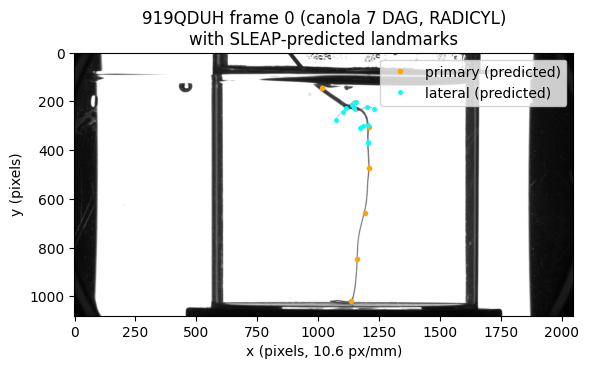

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

with h5py.File(DATA / "919QDUH.h5", "r") as f:
    dset = f["video"] if "video" in f else f[list(f.keys())[0]]
    img = dset[0]

fig, ax = plt.subplots(figsize=(6, 8))
ax.imshow(img, cmap="gray")
ax.set_title("919QDUH frame 0 (canola 7 DAG, RADICYL)\nwith SLEAP-predicted landmarks")
if prim0.size and not np.all(np.isnan(prim0)):
    for inst in prim0:
        ax.plot(inst[:, 0], inst[:, 1], ".", color="orange", ms=6, label="primary (predicted)")
if lat0.size and not np.all(np.isnan(lat0)):
    for inst in lat0:
        ax.plot(inst[:, 0], inst[:, 1], ".", color="cyan", ms=5, label="lateral (predicted)")
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles[:2], labels[:2], loc="upper right")
ax.set_xlabel("x (pixels, 10.6 px/mm)"); ax.set_ylabel("y (pixels)")
plt.tight_layout()
plt.savefig("/content/919QDUH_frame0_landmarks.png", dpi=110)
plt.show()

## 5. Compute dicot root traits with `DicotPipeline`

**What this does:** runs the authors' `DicotPipeline` over all 72 frames. For each frame it computes geometric traits of the primary and lateral roots — root lengths, angles, convex hull, ellipse fit, scanline crossings, tip counts, network length, and per-frame summaries — mirroring the paper's trait-extraction stage. The result is a DataFrame with one row per frame; we report its shape, the number of distinct scalar traits, and a preview of a few representative columns.
*日本語:* 著者の `DicotPipeline` を全72フレームに実行し、長さ・角度・凸包・楕円・走査線・チップ数などの形質を計算します。

In [ ]:
import time
from pathlib import Path
Path("/content/computed").mkdir(exist_ok=True)
pipeline = sr.DicotPipeline()
t0 = time.time()
traits = pipeline.compute_plant_traits(series, write_csv=True, output_dir="/content/computed")
elapsed = time.time() - t0
print(f"computed {traits.shape[0]} frames x {traits.shape[1]} columns in {elapsed:.1f} s")
print("distinct traits:", len(pipeline.csv_traits))
cols = ["plant_name", "frame_idx", "primary_length", "lateral_count", "lateral_lengths_mean"]
print(traits[cols].head())

computed 72 frames x 117 columns in 0.9 s
distinct traits: 115
  plant_name  frame_idx  primary_length  lateral_count  lateral_lengths_mean
0    919QDUH          0      971.050417              5             40.400556
1    919QDUH          1      967.768886              3             48.358489
2    919QDUH          2      971.479395              4             66.389865
3    919QDUH          3      958.449865              5             35.908835
4    919QDUH          4      951.056866              4             41.599796


## 6. Compare against the authors' reference output

**What this does:** loads the authors' committed reference table (`919QDUH.traits.csv`) for the same fixture and merges it with our computed traits on `frame_idx`. For every shared numeric trait column we compute the maximum absolute difference. Small differences may reflect package-version evolution between the reference generation and the pinned commit; large agreement confirms the pipeline reproduces the authors' trait-extraction behavior on their own example.
*日本語:* 著者公開の参照CSVと同じフレームで比較し、共通の数値形質列ごとに最大絶対誤差を求めます。

In [ ]:
import pandas as pd

ref = pd.read_csv(DATA / "919QDUH.traits.csv")
ref = ref[ref["plant_name"] == "919QDUH"] if "plant_name" in ref.columns else ref
ours = traits.copy()
merged = ours.merge(ref, on="frame_idx", suffixes=("_ours", "_ref"))
print("reference rows:", len(ref), "| merged rows:", len(merged))

common = []
for c in ours.columns:
    if c in ("plant_name", "frame_idx") or c.endswith("_ours") or c.endswith("_ref"):
        continue
    if c in ref.columns:
        a = pd.to_numeric(merged[f"{c}_ours"], errors="coerce")
        b = pd.to_numeric(merged[f"{c}_ref"], errors="coerce")
        ok = a.notna() & b.notna()
        if ok.any() and np.isfinite((a[ok] - b[ok]).abs().max()):
            common.append((c, float((a[ok] - b[ok]).abs().max()), int(ok.sum())))

print(f"shared numeric trait columns: {len(common)} / {len(pipeline.csv_traits)}")
diff_df = pd.DataFrame(common, columns=["trait", "max_abs_diff", "n_frames"]).sort_values(
    "max_abs_diff", ascending=False)
print("largest differences:"); print(diff_df.head(10).to_string(index=False))
print("exact-match (max_abs_diff == 0) columns:", int((diff_df['max_abs_diff'] == 0).sum()))

reference rows: 72 | merged rows: 72
shared numeric trait columns: 115 / 115
largest differences:
              trait  max_abs_diff  n_frames
         chull_area  1.455192e-11        72
          ellipse_a  1.301714e-11        72
          ellipse_b  8.384404e-13        72
      ellipse_ratio  4.565237e-13        72
    chull_perimeter  4.547474e-13        72
 lateral_tip_xs_p25  2.273737e-13        72
 lateral_tip_xs_p75  2.273737e-13        72
lateral_tip_xs_mean  2.273737e-13        72
     network_length  2.273737e-13        72
 lateral_tip_xs_p95  2.273737e-13        72
exact-match (max_abs_diff == 0) columns: 26


## 7. Trait profiles across the 72 frames

**What this does:** plots three representative traits — primary root length, mean lateral root length, and lateral root count — over all 72 rotation frames (one 5° step per frame). The stability of these profiles across viewing angles is exactly what the paper's pose-based approach is designed to deliver. This graph is an additional visualization created for this notebook, not an author figure.
*日本語:* 一次根長・側根平均長・側根数の72フレーム変化を描画します（本ノートブック独自の可視化であり、論文の図ではありません）。

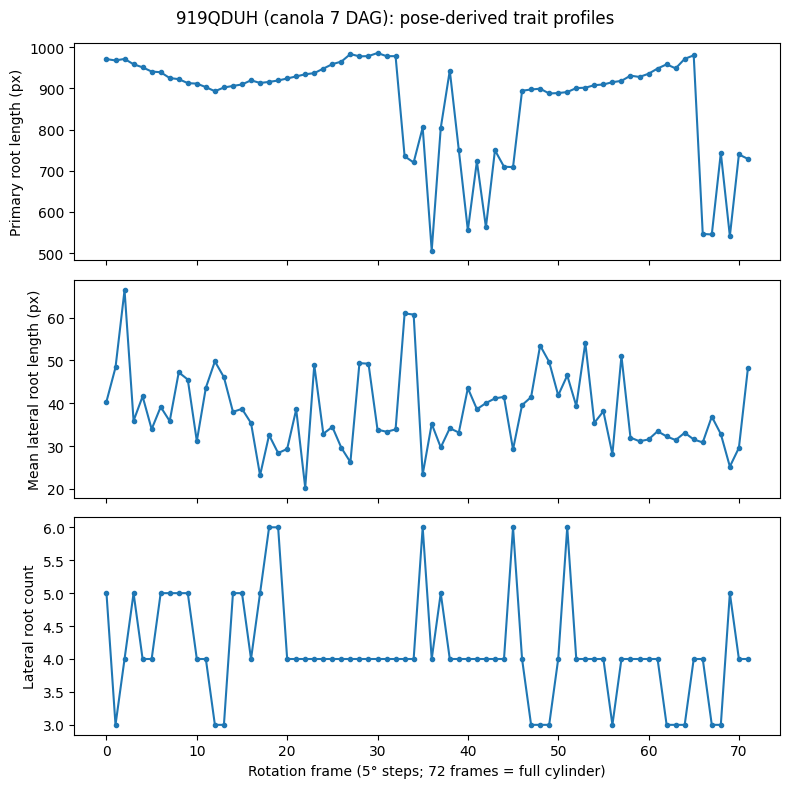

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
frames = traits["frame_idx"]
plot_specs = [
    ("primary_length", "Primary root length (px)"),
    ("lateral_lengths_mean", "Mean lateral root length (px)"),
    ("lateral_count", "Lateral root count"),
]
for ax, (col, label) in zip(axes, plot_specs):
    if col in traits.columns:
        ax.plot(frames, traits[col], marker="o", ms=3)
    ax.set_ylabel(label)
axes[-1].set_xlabel("Rotation frame (5° steps; 72 frames = full cylinder)")
fig.suptitle("919QDUH (canola 7 DAG): pose-derived trait profiles")
plt.tight_layout()
plt.savefig("/content/919QDUH_trait_profiles.png", dpi=110)
plt.show()

## 8. Export results

**What this does:** writes the computed trait table to CSV inside the Colab VM so the learner can download or inspect it. Units follow the input landmark coordinates (pixels at 10.6 px/mm); angles are in degrees.
*日本語:* 計算した形質表をCSVとして保存します（座標はピクセル、10.6 px/mm、角度は度）。

In [ ]:
out_csv = "/content/computed/919QDUH.traits.csv"
assert Path(out_csv).exists()
print("saved:", out_csv, Path(out_csv).stat().st_size, "bytes")
display(traits[["plant_name", "frame_idx", "primary_length", "lateral_count"]].describe())

saved: /content/computed/919QDUH.traits.csv 132734 bytes


,frame_idx,primary_length,lateral_count
count,72.00000,72.000000,72.000000
mean,35.50000,868.827882,4.125000
std,20.92845,125.013647,0.767977
min,0.00000,506.107332,3.000000
25%,17.75000,866.916605,4.000000
50%,35.50000,914.018389,4.000000
75%,53.25000,947.981993,4.000000
max,71.00000,985.867032,6.000000


## Interpretation and limitations

- **Executed scope:** the paper's landmark→trait stage on the authors' own canola fixture (1 plant, 72 frames), validated against the authors' committed reference traits. This demonstrates the trait-extraction pipeline, **not** the paper's SLEAP training/inference accuracy or dataset-level benchmarks.
- Landmark coordinates were predicted by the authors (committed `.predictions.slp`); no pose model is run here, so the 0.3–2.3 mm landmark-error results of the paper are not re-measured.
- Differences versus the reference CSV (if any) are reported above and may stem from sleap-roots version drift since the reference was generated.
- Units: coordinates/lengths in pixels (10.6 px/mm per the paper), angles in degrees, count traits unitless.

*日本語:* 実行したのは「ランドマーク→形質」段階のみであり、SLEAP推論やデータセット規模の評価は含みません。参照CSVとの差はパッケージ版数の差による可能性があります。

**References**
- Berrigan et al., Plant Phenomics 2024;6:0175 — https://doi.org/10.34133/plantphenomics.0175
- sleap-roots code: https://github.com/talmolab/sleap-roots (BSD-3-Clause), pinned commit `1d532cc19f4b48f834d2ec3c21dbac43f9813827`
- Fixture: `tests/data/canola_7do/919QDUH.*` from the same commit (Git LFS)